# Projeto 1: Análise estatística

🟢 Nível básico — exploração e métricas simples

Qual o faturamento total (valor_total) da empresa no período, e qual o ticket médio por pedido?


Quais são as 5 categorias de produto que mais vendem em quantidade e em receita? Elas coincidem?


Qual forma de pagamento é mais usada? E qual gera o maior valor médio por pedido?


Como o status_pedido se distribui (% de entregues, cancelados, devolvidos, etc.)? Isso é um problema para o negócio?


Qual região/estado concentra mais clientes e mais receita?


🟡 Nível intermediário — cruzamentos e tendências


A receita mensal está crescendo, caindo ou estável ao longo de 2023–2025? Existe sazonalidade (ex: dezembro maior que outros meses)?


Existe relação entre faixa etária do cliente e categoria de produto comprada (ex: jovens compram mais eletrônicos, idosos mais roupas)?


Qual a taxa de cancelamento/devolução por categoria de produto? Alguma categoria é "problemática"?


Clientes que pagam no boleto têm avaliação (avaliacao_cliente) diferente de quem paga no cartão? Isso pode indicar fricção na experiência de compra?


Qual o valor médio do pedido por região? Alguma região tem ticket médio muito acima/abaixo da média nacional?


🔴 Nível avançado — insight estratégico


Existe correlação entre avaliacao_cliente e status_pedido (pedidos cancelados/devolvidos recebem notas piores, como esperado)? Quantifique isso.


Segmente os clientes (RFM simplificado: quantos pedidos cada id_cliente fez, valor total gasto) e identifique os top 10% clientes por receita. Que % da receita eles representam?


Se a empresa quisesse reduzir devoluções em 20%, em qual categoria/estado/forma de pagamento ela deveria focar primeiro, com base nos dados?


Construa uma narrativa de "diagnóstico de negócio": 3 problemas que você identificaria nesse e-commerce e 3 recomendações baseadas puramente nos dados.


Há alguma variável (idade, região, forma de pagamento) que prediz melhor um pedido ser cancelado/devolvido? Como você testaria isso estatisticamente (ex: qui-quadrado, regressão logística)?

# importando as bibliotecas

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp

# importando os dados

In [2]:
df_limpo=pd.read_csv('Ecommerce_limpo.csv',parse_dates=['data_pedido'])
df= df_limpo.copy()

# entendendo os dados

In [3]:
df.head()

,id_pedido,data_pedido,id_cliente,nome_cliente,email,telefone,idade,cidade,estado,categoria_produto,produto,quantidade,preco_unitario,valor_total,forma_pagamento,status_pedido,avaliacao_cliente,regiao
0,1041,2023-07-26,306,Renan Ribeiro,leonardo88@example.org,NaN,59.0,Florianópolis,SC,Roupas,Camiseta Básica,2,49.9,99.8,Cartão De Débito,Devolvido,5,Sul
1,1047,2024-03-27,195,Diego Melo,novaisdavi@example.com,5.511973e+12,70.0,Contagem,MG,Roupas,Calça Jeans,4,129.9,519.6,Cartão De Débito,Processando,10,Sudeste
2,1344,2023-10-16,165,Nicole Moreira,liviacaldeira@example.com,NaN,49.0,Porto Alegre,RS,Esporte E Lazer,Bola De Futebol Oficial,4,89.9,359.6,Boleto Bancário,Cancelado,1,Sul
3,1137,2025-08-01,45,Fernanda Freitas,ucorreia@example.com,NaN,41.0,Olinda,PE,Roupas,Vestido Casual,3,159.9,479.7,Boleto Bancário,Em Transporte,1,Nordeste
4,1110,2023-08-27,149,Cecilia Novaes,ryanborges@example.org,5.585942e+12,29.0,Petrópolis,RJ,Roupas,Calça Jeans,2,129.9,259.8,Cartão De Crédito,Cancelado,1,Sudeste


In [4]:
df.tail()

,id_pedido,data_pedido,id_cliente,nome_cliente,email,telefone,idade,cidade,estado,categoria_produto,produto,quantidade,preco_unitario,valor_total,forma_pagamento,status_pedido,avaliacao_cliente,regiao
475,1168,2025-11-01,139,Aurora Oliveira,NaN,NaN,67.0,Contagem,MG,Roupas,Calça Jeans,1,129.9,129.9,Pix,Devolvido,4,Sudeste
476,1007,2024-12-25,109,Esther Freitas,novaesdavi-lucas@example.net,5.585931e+12,67.0,Santos,SP,Roupa,Jaqueta CortaVento,3,199.9,599.7,Cartão De Débito,Devolvido,4,Sudeste
477,1221,2024-03-17,265,Luiz Felipe Melo,nascimentopedro@example.net,5.511973e+12,59.0,Nan,RS,Eletrônicos,Notebook,2,3299.0,6598.0,Boleto Bancário,Devolvido,5,Sul
478,1462,2025-08-22,139,Davi Miguel Freitas,guerrarenan@example.org,5.579990e+12,36.0,Duque De Caxias,RJ,Roupas,Vestido Casual,2,159.9,319.8,Pix,Cancelado,5,Sudeste
479,1083,2023-10-17,224,Allana Rodrigues,enzo-gabrielalves@example.org,5.579961e+12,NaN,Sobral,CE,CasaDecoração,Luminária De Mesa,1,89.9,89.9,Boleto Bancário,Processando,2,Nordeste


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_pedido          480 non-null    int64         
 1   data_pedido        480 non-null    datetime64[ns]
 2   id_cliente         480 non-null    int64         
 3   nome_cliente       457 non-null    object        
 4   email              430 non-null    object        
 5   telefone           331 non-null    float64       
 6   idade              439 non-null    float64       
 7   cidade             473 non-null    object        
 8   estado             468 non-null    object        
 9   categoria_produto  480 non-null    object        
 10  produto            480 non-null    object        
 11  quantidade         480 non-null    int64         
 12  preco_unitario     480 non-null    float64       
 13  valor_total        471 non-null    float64       
 14  forma_paga

In [6]:
df=df.drop(columns=['id_cliente','nome_cliente','email','telefone'])

In [7]:
df

,id_pedido,data_pedido,idade,cidade,estado,categoria_produto,produto,quantidade,preco_unitario,valor_total,forma_pagamento,status_pedido,avaliacao_cliente,regiao
0,1041,2023-07-26,59.0,Florianópolis,SC,Roupas,Camiseta Básica,2,49.9,99.8,Cartão De Débito,Devolvido,5,Sul
1,1047,2024-03-27,70.0,Contagem,MG,Roupas,Calça Jeans,4,129.9,519.6,Cartão De Débito,Processando,10,Sudeste
2,1344,2023-10-16,49.0,Porto Alegre,RS,Esporte E Lazer,Bola De Futebol Oficial,4,89.9,359.6,Boleto Bancário,Cancelado,1,Sul
3,1137,2025-08-01,41.0,Olinda,PE,Roupas,Vestido Casual,3,159.9,479.7,Boleto Bancário,Em Transporte,1,Nordeste
4,1110,2023-08-27,29.0,Petrópolis,RJ,Roupas,Calça Jeans,2,129.9,259.8,Cartão De Crédito,Cancelado,1,Sudeste
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,1168,2025-11-01,67.0,Contagem,MG,Roupas,Calça Jeans,1,129.9,129.9,Pix,Devolvido,4,Sudeste
476,1007,2024-12-25,67.0,Santos,SP,Roupa,Jaqueta CortaVento,3,199.9,599.7,Cartão De Débito,Devolvido,4,Sudeste
477,1221,2024-03-17,59.0,Nan,RS,Eletrônicos,Notebook,2,3299.0,6598.0,Boleto Bancário,Devolvido,5,Sul
478,1462,2025-08-22,36.0,Duque De Caxias,RJ,Roupas,Vestido Casual,2,159.9,319.8,Pix,Cancelado,5,Sudeste


# Análise exploratória de dados

In [8]:
df.describe()
# É possível notar que as colunas preco_unitario e valor_total apresentam maior variabilidade, evidenciada pelo elevado desvio padrão e pela grande diferença entre a média e a mediana. Além disso, como a média é superior à mediana, há indícios de assimetria positiva.

,id_pedido,data_pedido,idade,quantidade,preco_unitario,valor_total,avaliacao_cliente
count,480.000000,480,439.000000,480.000000,480.000000,471.000000,480.000000
mean,1240.500000,2024-08-01 05:15:00.000000256,44.801822,2.254167,493.200312,1198.313822,3.787500
min,1001.000000,2023-01-05 00:00:00,18.000000,0.000000,29.900000,28.410000,0.000000
25%,1120.750000,2023-11-27 06:00:00,30.500000,1.000000,79.900000,99.900000,3.000000
50%,1240.500000,2024-07-22 00:00:00,44.000000,2.000000,149.900000,299.700000,4.000000
75%,1360.250000,2025-05-02 06:00:00,58.000000,3.000000,289.900000,999.000000,4.000000
max,1480.000000,2025-12-27 00:00:00,75.000000,5.000000,3299.000000,16495.000000,10.000000
std,138.708327,NaN,16.474954,1.310780,770.237813,2302.325310,1.421814


array([[<Axes: title={'center': 'idade'}>,
        <Axes: title={'center': 'quantidade'}>],
       [<Axes: title={'center': 'preco_unitario'}>,
        <Axes: title={'center': 'valor_total'}>],
       [<Axes: title={'center': 'avaliacao_cliente'}>, <Axes: >]],
      dtype=object)

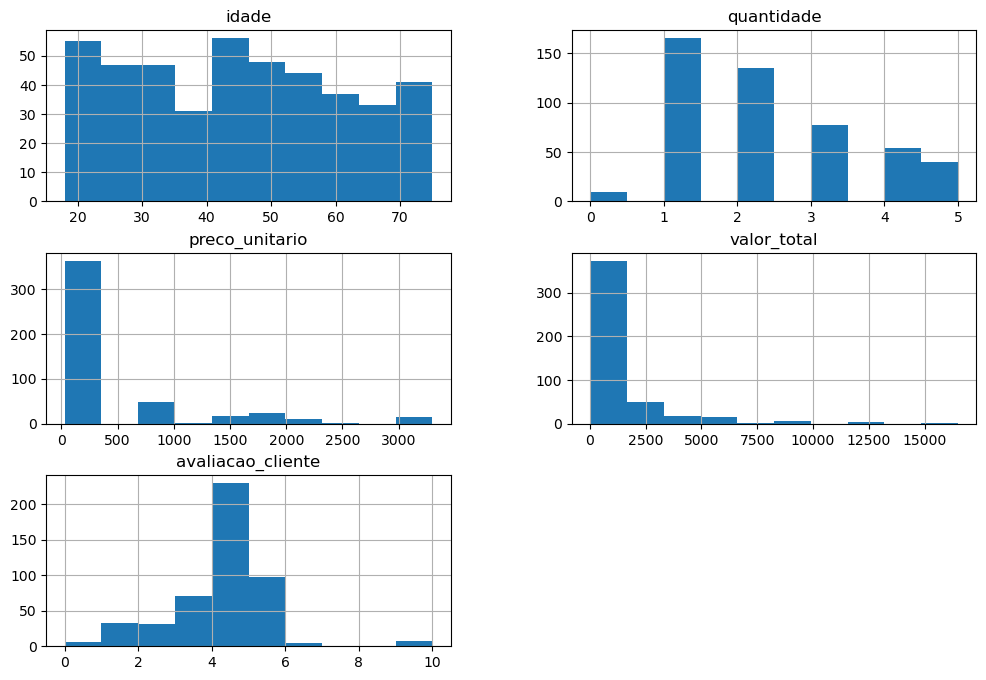

In [17]:
colum=['idade','quantidade','preco_unitario','valor_total','avaliacao_cliente']
df[colum].hist(figsize=(12,8),bins=10)